# Elastic Net Linear Regression: 
### Combined L1+L2 penalty, mixing parameter alpha


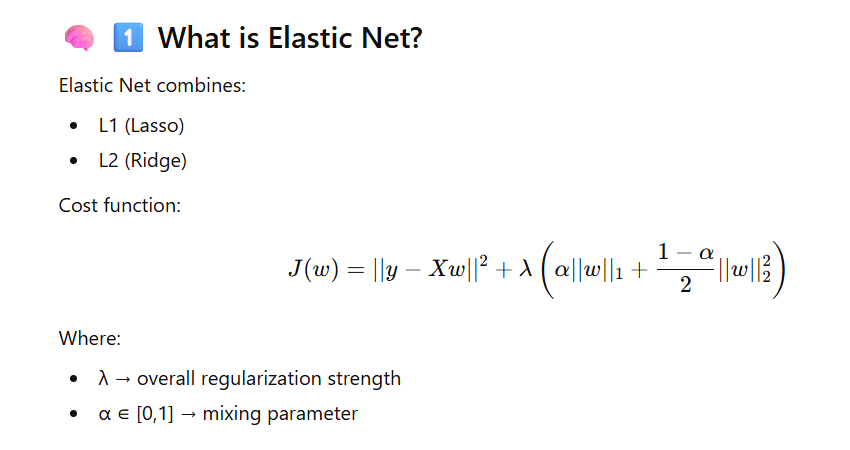

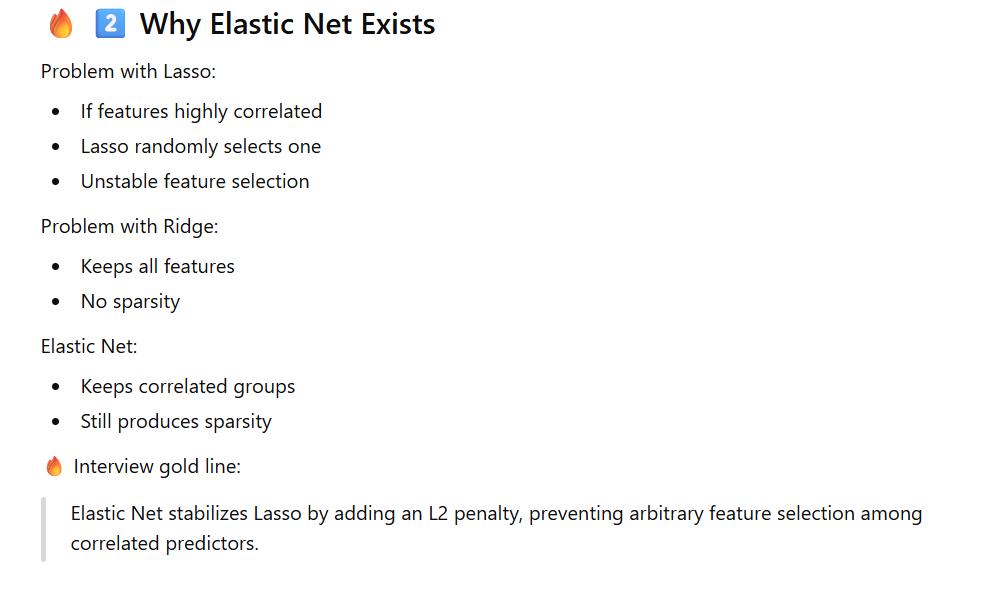

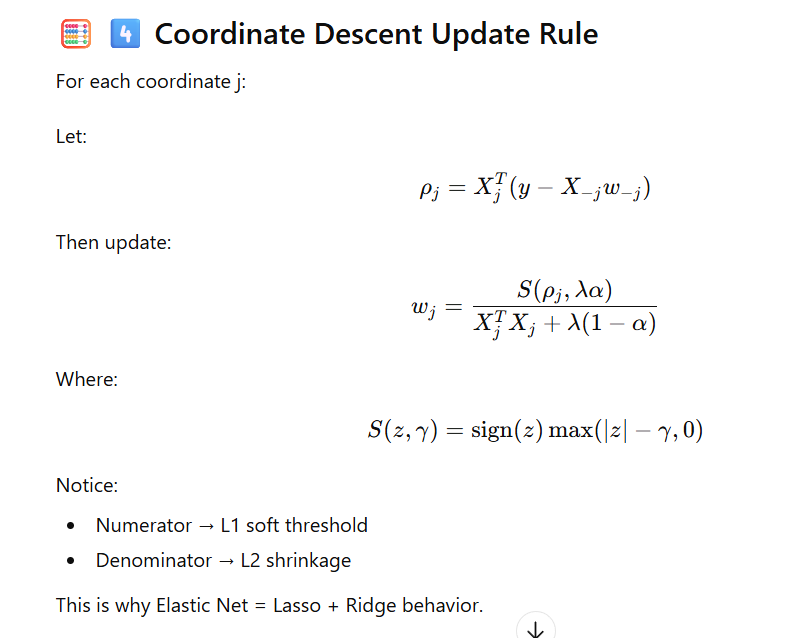

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def soft_threshold(z, gamma):
    return np.sign(z) * np.maximum(np.abs(z) - gamma, 0.0)

In [3]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std, mean, std


In [4]:
def elastic_net_coordinate_descent(X, y, lam, alpha, iterations=1000):
    m, n = X.shape
    w = np.zeros(n)

    for _ in range(iterations):
        for j in range(n):
            # Compute residual excluding j
            y_pred = X @ w
            residual = y - y_pred + X[:, j] * w[j]

            rho = np.dot(X[:, j], residual)

            # Update rule
            w[j] = soft_threshold(rho, lam * alpha) / \
                (np.dot(X[:, j], X[:, j]) + lam * (1-alpha))
    
    return w

In [5]:
# np.random.seed(42)

# X = np.random.randn(100, 20)

# true_w = np.zeros(20)
# true_w[:5] = [5,3,0,2,0]

# y = X @ true_w + np.random.randn(100)*0.5

# X_std, _, _ = standardize(X)

# lam = 1.0
# alpha = 0.5

# w = elastic_net_coordinate_descent(X_std, y, lam, alpha)

# print("True weights:", true_w)
# print("Estimated weights:", w)

In [6]:
np.random.seed(42)

m = 150
n = 20

X = np.random.randn(m,n)

X[:, 5] = X[:, 0] + np.random.randn(m) * 0.1
X[:, 6] = X[:, 0] + np.random.randn(m) * 0.1

true_w = np.zeros(n)
true_w[0] = 5
true_w[3] = 3
true_w[10] = 2

y = X @ true_w + np.random.randn(m) * 0.5

X_std, mean, std = standardize(X)

In [7]:
# Train Models
lam = 1.0
w_lasso = elastic_net_coordinate_descent(X_std, y, lam=lam, alpha=1.0)
w_ridge = elastic_net_coordinate_descent(X_std, y, lam=lam, alpha=0.0)
w_enet = elastic_net_coordinate_descent(X_std, y, lam=lam, alpha=0.5)

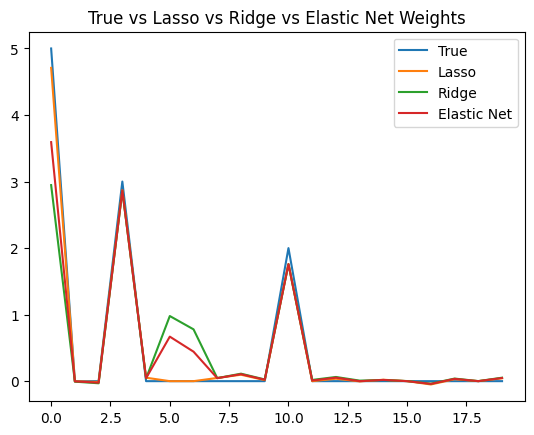

In [8]:
# Plot Weight Comparison

plt.figure()
plt.plot(true_w)
plt.plot(w_lasso)
plt.plot(w_ridge)
plt.plot(w_enet)
plt.title("True vs Lasso vs Ridge vs Elastic Net Weights")
plt.legend(["True", "Lasso", "Ridge", "Elastic Net"])
plt.show()

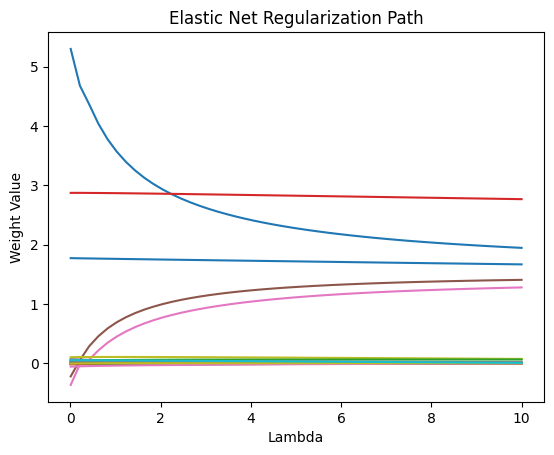

In [17]:
# -----------------------------
# 7️⃣ Regularization Path (Elastic Net)
# -----------------------------
lambdas = np.linspace(0.01, 10, 50)
weights_path = []

for lam_val in lambdas:
    w_temp = elastic_net_coordinate_descent(X_std, y, lam=lam_val, alpha=0.5, iterations=300)
    weights_path.append(w_temp)

weights_path = np.array(weights_path)

plt.figure()
for i in range(n):
    plt.plot(lambdas, weights_path[:, i])
plt.title("Elastic Net Regularization Path")
plt.xlabel("Lambda")
plt.ylabel("Weight Value")
plt.show()

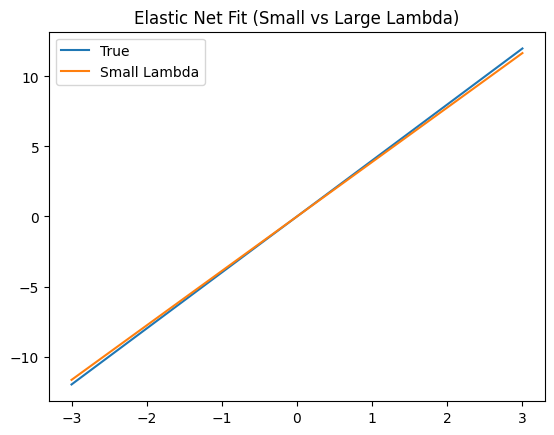

In [14]:
# Prediction visualization

X_1d = np.linspace(-3, 3, 100).reshape(-1, 1)
y_true = 4*X_1d.squeeze()

X_1d_std, m1, s1 = standardize(X_1d)

w_small = elastic_net_coordinate_descent(X_1d_std, y_true, lam=0.1, alpha=0.5)
w_large = elastic_net_coordinate_descent(X_1d_std, y_true, lam=5.0, alpha=0.5)

y_pred_small = X_1d_std @ w_small
y_pred_large = X_1d_std @ w_large

plt.figure()
plt.plot(X_1d, y_pred_small)
plt.plot(X_1d, y_pred_large)
plt.title("Elastic Net Fit (Small vs Large Lambda)")
plt.legend(["True", "Small Lambda", "Large Lambda"])
plt.show()

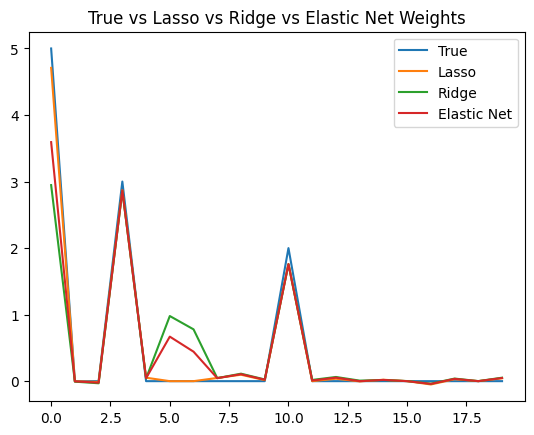

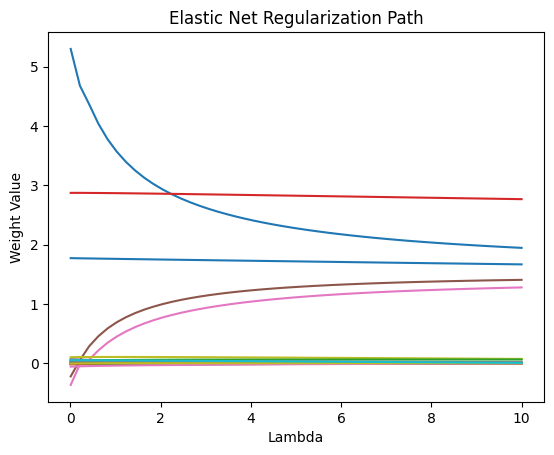

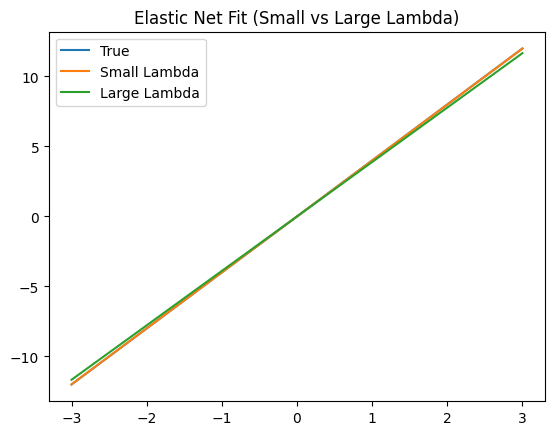

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Soft Threshold Function
# -----------------------------
def soft_threshold(z, gamma):
    return np.sign(z) * np.maximum(np.abs(z) - gamma, 0.0)


# -----------------------------
# 2️⃣ Standardization
# -----------------------------
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std, mean, std


# -----------------------------
# 3️⃣ Elastic Net (Coordinate Descent)
# -----------------------------
def elastic_net_cd(X, y, lam, alpha, iterations=1000):
    m, n = X.shape
    w = np.zeros(n)

    for _ in range(iterations):
        for j in range(n):

            y_pred = X @ w
            residual = y - y_pred + X[:, j] * w[j]

            rho = np.dot(X[:, j], residual)

            w[j] = soft_threshold(rho, lam * alpha) / \
                   (np.dot(X[:, j], X[:, j]) + lam * (1 - alpha))

    return w


# -----------------------------
# 4️⃣ Create Correlated Dataset
# -----------------------------
np.random.seed(42)

m = 150
n = 20

X = np.random.randn(m, n)

# Make features correlated
X[:, 5] = X[:, 0] + np.random.randn(m) * 0.1
X[:, 6] = X[:, 0] + np.random.randn(m) * 0.1

true_w = np.zeros(n)
true_w[0] = 5
true_w[3] = 3
true_w[10] = 2

y = X @ true_w + np.random.randn(m) * 0.5

X_std, mean, std = standardize(X)

# -----------------------------
# 5️⃣ Train Models
# -----------------------------
lam = 1.0

w_lasso = elastic_net_cd(X_std, y, lam=lam, alpha=1.0)
w_ridge = elastic_net_cd(X_std, y, lam=lam, alpha=0.0)
w_enet  = elastic_net_cd(X_std, y, lam=lam, alpha=0.5)


# -----------------------------
# 6️⃣ Plot Weight Comparison
# -----------------------------
plt.figure()
plt.plot(true_w)
plt.plot(w_lasso)
plt.plot(w_ridge)
plt.plot(w_enet)
plt.title("True vs Lasso vs Ridge vs Elastic Net Weights")
plt.legend(["True", "Lasso", "Ridge", "Elastic Net"])
plt.show()


# -----------------------------
# 7️⃣ Regularization Path (Elastic Net)
# -----------------------------
lambdas = np.linspace(0.01, 10, 50)
weights_path = []

for lam_val in lambdas:
    w_temp = elastic_net_cd(X_std, y, lam=lam_val, alpha=0.5, iterations=300)
    weights_path.append(w_temp)

weights_path = np.array(weights_path)

plt.figure()
for i in range(n):
    plt.plot(lambdas, weights_path[:, i])
plt.title("Elastic Net Regularization Path")
plt.xlabel("Lambda")
plt.ylabel("Weight Value")
plt.show()


# -----------------------------
# 8️⃣ Prediction Visualization (1D Example)
# -----------------------------
X_1d = np.linspace(-3, 3, 100).reshape(-1, 1)
y_true = 4 * X_1d.squeeze()

X_1d_std, m1, s1 = standardize(X_1d)

w_small = elastic_net_cd(X_1d_std, y_true, lam=0.1, alpha=0.5)
w_large = elastic_net_cd(X_1d_std, y_true, lam=5.0, alpha=0.5)

y_pred_small = X_1d_std @ w_small
y_pred_large = X_1d_std @ w_large

plt.figure()
plt.plot(X_1d, y_true)
plt.plot(X_1d, y_pred_small)
plt.plot(X_1d, y_pred_large)
plt.title("Elastic Net Fit (Small vs Large Lambda)")
plt.legend(["True", "Small Lambda", "Large Lambda"])
plt.show()